# Independent Local Training on Non-IID Data

## Notebook Overview 

**Purpose:** Explore what happens when separate models learn from incomplete, non-IID data. 

**Dataset:** MNIST handwritten digits (classes 0–9). 

**Experiment:** Split MNIST into three data silos, remove different digit classes from each silo, and train one CNN model per silo. 

**Analysis:** Compare class distributions, test accuracy, and confusion matrices to identify each model’s blind spots.

### Before You Begin

**Prerequisite:** Basic knowledge of Convolutional Neural Networks (CNNs) is required. If you are not confident with CNN concepts and architectures, please review the [CNN materials](https://github.com/TurgudValiyev2002/Computer-Vision/tree/672ef658ad735703168cfd73a843da7acc38b7da/CNN) before continuing.

This notebook requires **Python**, **PyTorch**, **Torchvision**, **NumPy**, **Matplotlib**, and **scikit-learn**. An internet connection is needed only for the first automatic MNIST download; later runs use the local copy.

A CUDA GPU speeds up training but is not required. For a reproducible classroom run, execute the notebook from top to bottom using **Restart Kernel and Run All**.

### 1. Library Import

In [ ]:
# Standard library
import random

# Data and visualization
import numpy as np
import matplotlib.pyplot as plt

# Deep learning
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, random_split, Subset
from torchvision import datasets, transforms

# Evaluation
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay

# Reproducibility
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

print("All libraries imported successfully.")
print("PyTorch version:", torch.__version__)

All libraries imported successfully.
PyTorch version: 2.11.0+cu128


### 2. Load and Inspect the MNIST Dataset

In [19]:
# Convert each image to a normalized PyTorch tensor
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.1307,), (0.3081,)),
])

DATA_DIR = "./MNIST_data/"

# download=True downloads MNIST only when it is not already available
trainset = datasets.MNIST(
    root=DATA_DIR,
    train=True,
    download=True,
    transform=transform,
)

testset = datasets.MNIST(
    root=DATA_DIR,
    train=False,
    download=True,
    transform=transform,
)

### Manual Download Links

Both the image file and its corresponding label file are required for each split:

- **Training images:** [train-images-idx3-ubyte.gz](https://ossci-datasets.s3.amazonaws.com/mnist/train-images-idx3-ubyte.gz)
- **Training labels:** [train-labels-idx1-ubyte.gz](https://ossci-datasets.s3.amazonaws.com/mnist/train-labels-idx1-ubyte.gz)
- **Test images:** [t10k-images-idx3-ubyte.gz](https://ossci-datasets.s3.amazonaws.com/mnist/t10k-images-idx3-ubyte.gz)
- **Test labels:** [t10k-labels-idx1-ubyte.gz](https://ossci-datasets.s3.amazonaws.com/mnist/t10k-labels-idx1-ubyte.gz)

Sources: [Torchvision MNIST documentation](https://docs.pytorch.org/vision/stable/generated/torchvision.datasets.MNIST.html) and [Torchvision MNIST source](https://docs.pytorch.org/vision/stable/_modules/torchvision/datasets/mnist.html). The code above downloads the same files automatically when `download=True`.


In [20]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print(f"Training samples: {len(trainset):,}")
print(f"Test samples:     {len(testset):,}")
print(f"Classes:          {trainset.classes}")

image, label = trainset[0]
print(f"Image shape:      {tuple(image.shape)}")
print(f"Example label:    {label}")
print(f"CUDA available:   {torch.cuda.is_available()}")
print(f"Selected device:  {device}")

if torch.cuda.is_available():
    print(f"GPU:              {torch.cuda.get_device_name(0)}")

Training samples: 60,000
Test samples:     10,000
Classes:          ['0 - zero', '1 - one', '2 - two', '3 - three', '4 - four', '5 - five', '6 - six', '7 - seven', '8 - eight', '9 - nine']
Image shape:      (1, 28, 28)
Example label:    5
CUDA available:   True
Selected device:  cuda
GPU:              NVIDIA RTX 2000 Ada Generation


#### 2.1 Visualize MNIST Examples

Training samples: 60,000
Test samples:     10,000
Classes:          ['0 - zero', '1 - one', '2 - two', '3 - three', '4 - four', '5 - five', '6 - six', '7 - seven', '8 - eight', '9 - nine']
Image shape:      (1, 28, 28)
Example label:    5


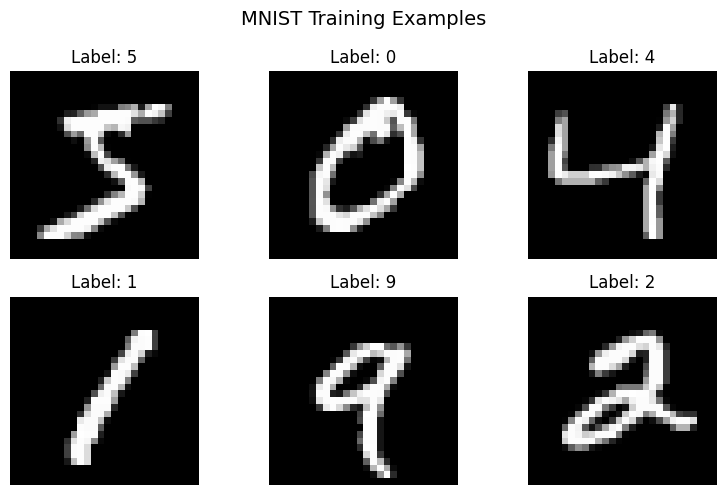

In [21]:
print(f"Training samples: {len(trainset):,}")
print(f"Test samples:     {len(testset):,}")
print(f"Classes:          {trainset.classes}")

image, label = trainset[0]
print(f"Image shape:      {tuple(image.shape)}")
print(f"Example label:    {label}")

# Display six training examples
fig, axes = plt.subplots(2, 3, figsize=(8, 5))
for index, axis in enumerate(axes.flat):
    sample_image, sample_label = trainset[index]
    axis.imshow(sample_image.squeeze(), cmap="gray")
    axis.set_title(f"Label: {sample_label}")
    axis.axis("off")

fig.suptitle("MNIST Training Examples", fontsize=14)
plt.tight_layout()
plt.show()

### MNIST Dataset Summary

MNIST is a labeled image-classification dataset of handwritten digits:

- **Training set:** 60,000 images
- **Test set:** 10,000 images
- **Image format:** 28 x 28 grayscale pixels with one channel
- **Classes:** 10 digits, from **0 to 9**
- **Task:** Predict the digit shown in each image

Each sample is an **image-label pair**, rather than a conventional tabular row.

---

### 3. Create Non-IID Client Partitions

In [22]:
# Create three equal random base partitions
partition_size = len(trainset) // 3
partition_sizes = [
    partition_size,
    partition_size,
    len(trainset) - (2 * partition_size),
]

client_1_base, client_2_base, client_3_base = random_split(
    trainset,
    partition_sizes,
    generator=torch.Generator().manual_seed(SEED),
)

print("Base partitions created:")
print(f"Client 1: {len(client_1_base):,} samples")
print(f"Client 2: {len(client_2_base):,} samples")
print(f"Client 3: {len(client_3_base):,} samples")
print(f"Total:    {sum(partition_sizes):,} samples")

Base partitions created:
Client 1: 20,000 samples
Client 2: 20,000 samples
Client 3: 20,000 samples
Total:    60,000 samples


#### 3.1 Partition Strategy

We use a **class-missing, label-skew non-IID partition**:

1. Randomly divide the 60,000 MNIST training images into three equal base partitions.

2. Remove a different group of digit classes from each client:

   - **Client 1:** missing digits 1, 3, and 7

   - **Client 2:** missing digits 2, 5, and 8

   - **Client 3:** missing digits 4, 6, and 9

The clients therefore have different label distributions and incomplete local knowledge. This is a deliberately strong non-IID setting designed to reveal model blind spots.


#### 3.2 Helper Functions

**`_get_targets()`** - Extracts all class labels from a MNIST dataset or PyTorch `Subset`. It also preserves the correct label indices when working with a subset.

**`exclude_digits()`** - Creates a new dataset by removing samples belonging to the specified digit classes. We use it to construct class-missing, non-IID client datasets.

**`include_digits()`** - Creates a new dataset containing only the specified digit classes. It is useful for building focused test sets that measure performance on each client’s missing classes.

**`plot_distribution()`** -  Displays the number of samples belonging to each digit class in one dataset. This helps us identify missing classes and class imbalance.

**`compare_distributions()`** - Displays the class distributions of multiple client datasets in one grouped bar chart. It makes the statistical differences between the non-IID clients easy to compare.

**`summarize_dataset()`** - Prints the sample count and the number of examples for each available digit.

In [23]:
def _get_targets(ds):
    """Return a 1D LongTensor of labels for a dataset or Subset."""
    if isinstance(ds, Subset):
        parent = ds.dataset
        idxs = ds.indices
        targets = getattr(parent, "targets", None)
        if isinstance(targets, list):
            targets = torch.tensor(targets)
        if targets is None:
            # very rare fallback
            return torch.tensor([lbl for _, lbl in ds], dtype=torch.long)
        return targets[idxs].clone().long()
    else:
        targets = getattr(ds, "targets", None)
        if isinstance(targets, list):
            targets = torch.tensor(targets)
        if targets is None:
            return torch.tensor([lbl for _, lbl in ds], dtype=torch.long)
        return targets.clone().long()


def exclude_digits(ds, excluded_digits):
    """Return a Subset excluding the specified digits."""
    targets = _get_targets(ds)
    mask = ~np.isin(targets.numpy(), np.array(excluded_digits, dtype=np.int64))
    if isinstance(ds, Subset):
        idxs = np.array(ds.indices)[mask]
        return Subset(ds.dataset, idxs.tolist())
    else:
        idxs = np.nonzero(mask)[0]
        return Subset(ds, idxs.tolist())


def include_digits(ds, included_digits):
    """Return a Subset including only the specified digits."""
    targets = _get_targets(ds)
    mask = np.isin(targets.numpy(), np.array(included_digits, dtype=np.int64))
    if isinstance(ds, Subset):
        idxs = np.array(ds.indices)[mask]
        return Subset(ds.dataset, idxs.tolist())
    else:
        idxs = np.nonzero(mask)[0]
        return Subset(ds, idxs.tolist())

    


# Plotting & Summary Functions


def plot_distribution(ds, title):
    labels = _get_targets(ds).numpy()
    counts = np.bincount(labels, minlength=10)

    plt.figure(figsize=(8, 4))
    plt.bar(range(10), counts, edgecolor='black')
    plt.title(f"Digit Distribution in {title}")
    plt.xlabel("Digit")
    plt.ylabel("Frequency")
    plt.xticks(range(10))
    plt.grid(axis='y', linestyle='--', alpha=0.6)
    plt.tight_layout()
    plt.show()
    plt.close()


def compare_distributions(datasets, names):
    """Grouped bar chart to compare the three parts side-by-side."""
    all_counts = [np.bincount(_get_targets(ds).numpy(), minlength=10) for ds in datasets]
    x = np.arange(10)
    width = 0.25

    plt.figure(figsize=(10, 4))
    for i, (counts, name) in enumerate(zip(all_counts, names)):
        plt.bar(x + (i-1)*width, counts, width=width, label=name, edgecolor='black')
    plt.xticks(x, list(range(10)))
    plt.xlabel("Digit")
    plt.ylabel("Frequency")
    plt.title("Digit Distribution Across Non-IID Parts")
    plt.legend()
    plt.grid(axis='y', linestyle='--', alpha=0.6)
    plt.tight_layout()
    plt.show()
    plt.close()


def summarize(dataset, name):
    """Print the sample count and per-digit distribution."""
    labels = _get_targets(dataset).numpy()
    counts = np.bincount(labels, minlength=10)
    present_counts = {digit: int(count) for digit, count in enumerate(counts) if count > 0}
    print(f"{name}: {len(labels):,} samples")
    print("Digit counts:", present_counts)
    print()

The helper functions above filter digit classes and visualize each client's label distribution.

#### 3.3 Build and Check the Client Partitions

In [24]:
# Create the final class-missing non-IID client datasets
client_1_train = exclude_digits(client_1_base, [1, 3, 7])
client_2_train = exclude_digits(client_2_base, [2, 5, 8])
client_3_train = exclude_digits(client_3_base, [4, 6, 9])

summarize(client_1_train, "Client 1 training data (missing 1, 3, 7)")
summarize(client_2_train, "Client 2 training data (missing 2, 5, 8)")
summarize(client_3_train, "Client 3 training data (missing 4, 6, 9)")

Client 1 training data (missing 1, 3, 7): 13,729 samples
Digit counts: {0: 2018, 2: 1943, 4: 1957, 5: 1862, 6: 1995, 8: 1967, 9: 1987}

Client 2 training data (missing 2, 5, 8): 14,284 samples
Digit counts: {0: 1965, 1: 2268, 3: 2009, 4: 1990, 6: 1971, 7: 2087, 9: 1994}

Client 3 training data (missing 4, 6, 9): 14,185 samples
Digit counts: {0: 1940, 1: 2245, 2: 1983, 3: 2102, 5: 1770, 7: 2156, 8: 1989}



#### 3.4. Visualize the Client Distributions

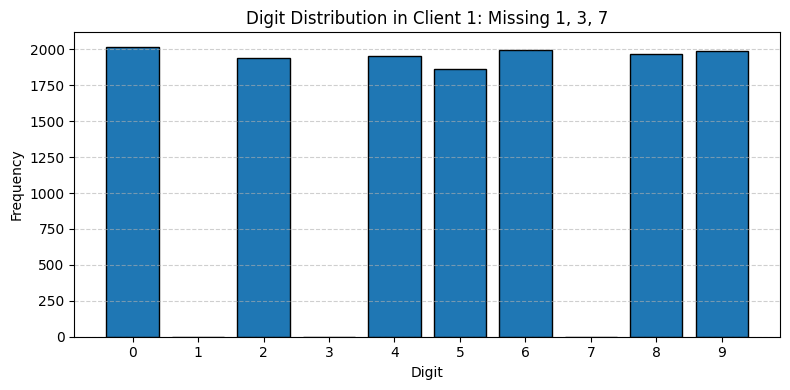

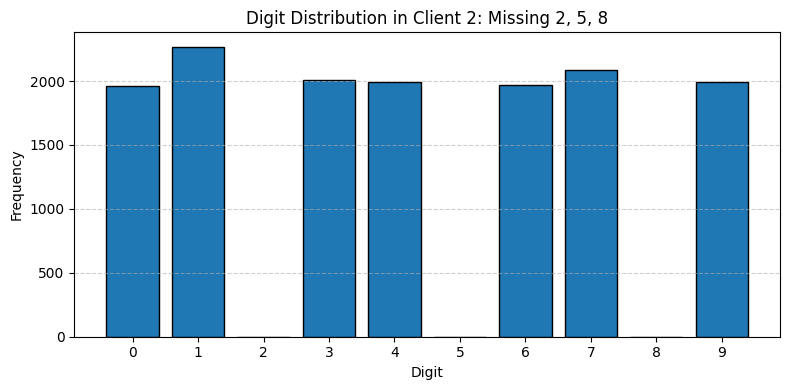

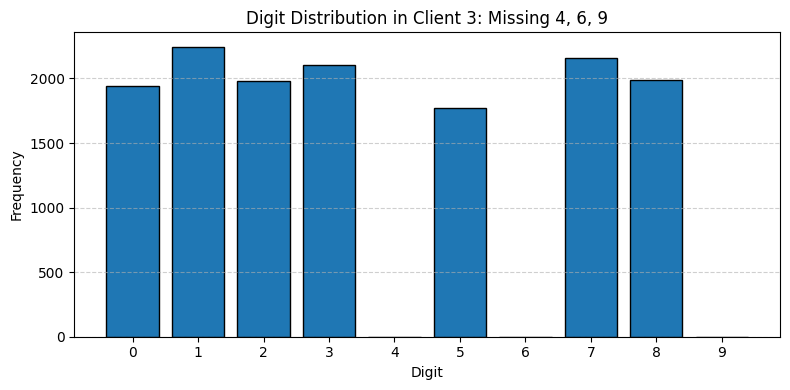

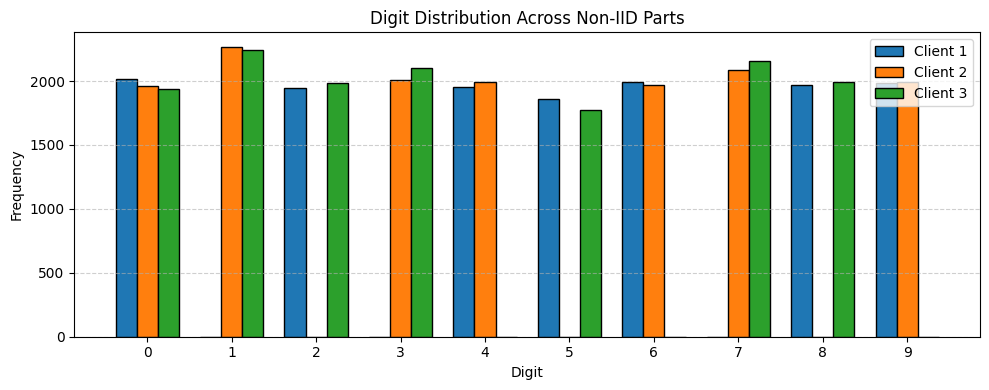

In [25]:
plot_distribution(client_1_train, "Client 1: Missing 1, 3, 7")
plot_distribution(client_2_train, "Client 2: Missing 2, 5, 8")
plot_distribution(client_3_train, "Client 3: Missing 4, 6, 9")

compare_distributions(
    [client_1_train, client_2_train, client_3_train],
    ["Client 1", "Client 2", "Client 3"],
)

---

### 4. Creating Test Subsets

#### 4.1 Seen-Class and Missing-Class Test Sets

In [26]:
# Build focused test sets for classes seen and not seen during local training
client_1_seen_classes_test = exclude_digits(testset, [1, 3, 7])
client_2_seen_classes_test = exclude_digits(testset, [2, 5, 8])
client_3_seen_classes_test = exclude_digits(testset, [4, 6, 9])

client_1_missing_classes_test = include_digits(testset, [1, 3, 7])
client_2_missing_classes_test = include_digits(testset, [2, 5, 8])
client_3_missing_classes_test = include_digits(testset, [4, 6, 9])

print(f"Global test set: {len(testset):,} samples")
print()
print("Client 1 | seen classes: "
      f"{len(client_1_seen_classes_test):,} | missing classes [1, 3, 7]: "
      f"{len(client_1_missing_classes_test):,}")
print("Client 2 | seen classes: "
      f"{len(client_2_seen_classes_test):,} | missing classes [2, 5, 8]: "
      f"{len(client_2_missing_classes_test):,}")
print("Client 3 | seen classes: "
      f"{len(client_3_seen_classes_test):,} | missing classes [4, 6, 9]: "
      f"{len(client_3_missing_classes_test):,}")

Global test set: 10,000 samples

Client 1 | seen classes: 6,827 | missing classes [1, 3, 7]: 3,173
Client 2 | seen classes: 7,102 | missing classes [2, 5, 8]: 2,898
Client 3 | seen classes: 7,051 | missing classes [4, 6, 9]: 2,949


Each client now has two focused evaluation sets: one containing the digit classes it **saw during training** and one containing the classes that were **missing from its training data**. This makes the model's learned knowledge and blind spots directly comparable.

#### 4.2 Global Test Set

In [27]:
# Inspect the complete test set used to evaluate every client model
print("Global test set")
print(f"Samples: {len(testset):,}")
print("Digits:  0-9")

test_image, test_label = testset[0]
print(f"Image shape: {tuple(test_image.shape)}")
print(f"Example label: {test_label}")

Global test set
Samples: 10,000
Digits:  0-9
Image shape: (1, 28, 28)
Example label: 7


The **global test set** is the complete official MNIST test split. It contains all digits from 0 to 9 and is used unchanged for every client model.

---

### 5. Dataset Partitioning Summary

In [28]:
training_partitions = [client_1_train, client_2_train, client_3_train]
retained_training_samples = sum(len(dataset) for dataset in training_partitions)
discarded_training_samples = len(trainset) - retained_training_samples

print("TRAINING PARTITIONS")
print(f"Client 1 (missing 1, 3, 7): {len(client_1_train):,} samples")
print(f"Client 2 (missing 2, 5, 8): {len(client_2_train):,} samples")
print(f"Client 3 (missing 4, 6, 9): {len(client_3_train):,} samples")
print(f"Total retained:              {retained_training_samples:,} samples")
print(
    f"Removed by class filtering:  {discarded_training_samples:,} samples "
    f"({discarded_training_samples / len(trainset) * 100:.1f}%)"
)

print()
print("EVALUATION DATASETS")
print(f"Global test set (digits 0-9): {len(testset):,} samples")
print(
    f"Client 1 | seen: {len(client_1_seen_classes_test):,} | "
    f"missing [1, 3, 7]: {len(client_1_missing_classes_test):,}"
)
print(
    f"Client 2 | seen: {len(client_2_seen_classes_test):,} | "
    f"missing [2, 5, 8]: {len(client_2_missing_classes_test):,}"
)
print(
    f"Client 3 | seen: {len(client_3_seen_classes_test):,} | "
    f"missing [4, 6, 9]: {len(client_3_missing_classes_test):,}"
)

TRAINING PARTITIONS
Client 1 (missing 1, 3, 7): 13,729 samples
Client 2 (missing 2, 5, 8): 14,284 samples
Client 3 (missing 4, 6, 9): 14,185 samples
Total retained:              42,198 samples
Removed by class filtering:  17,802 samples (29.7%)

EVALUATION DATASETS
Global test set (digits 0-9): 10,000 samples
Client 1 | seen: 6,827 | missing [1, 3, 7]: 3,173
Client 2 | seen: 7,102 | missing [2, 5, 8]: 2,898
Client 3 | seen: 7,051 | missing [4, 6, 9]: 2,949


| Dataset | Role | Digit classes |
| --- | --- | --- |
| **client_1_train** | Client 1 training data | 0, 2, 4, 5, 6, 8, 9 (missing 1, 3, 7) |
| **client_2_train** | Client 2 training data | 0, 1, 3, 4, 6, 7, 9 (missing 2, 5, 8) |
| **client_3_train** | Client 3 training data | 0, 1, 2, 3, 5, 7, 8 (missing 4, 6, 9) |
| **testset** | Global evaluation | All digits, 0-9 |
| **client_1_seen_classes_test** | Tests Client 1's learned classes | 0, 2, 4, 5, 6, 8, 9 |
| **client_1_missing_classes_test** | Tests Client 1's blind spots | 1, 3, 7 |
| **client_2_seen_classes_test** | Tests Client 2's learned classes | 0, 1, 3, 4, 6, 7, 9 |
| **client_2_missing_classes_test** | Tests Client 2's blind spots | 2, 5, 8 |
| **client_3_seen_classes_test** | Tests Client 3's learned classes | 0, 1, 2, 3, 5, 7, 8 |
| **client_3_missing_classes_test** | Tests Client 3's blind spots | 4, 6, 9 |

**Important:** Class filtering intentionally removes some training images. The experiment retains 42,198 of the original 60,000 training samples; the removed images are not reassigned to another client.

---

### 6. CNN Model

Each client trains its **own CNN model** using only its local non-IID training partition. The clients do not share raw data, model parameters, or predictions.

**Workflow**

1. Define one CNN architecture and a common set of hyperparameters.

2. Create a fresh model for each client.

3. Train each model independently on its client's local data.

4. Evaluate each model on the global test set and on its missing digit classes.

#### 6.1 Model Configurations

| **Component**             | **Value**        | **Purpose / Why Used**                                                                    |
| ------------------------- | ---------------- | ----------------------------------------------------------------------------------------- |
| **Optimizer**             | Adam             | Handles noisy, non-IID gradients effectively and converges faster without heavy tuning.   |
| **Loss Function**         | CrossEntropyLoss | Standard loss for multi-class classification problems like MNIST.                         |
| **Epochs per Client**     | 6                | Allows sufficient local learning while avoiding overfitting during each FL round.         |
| **Batch Size**            | 128              | Provides stable gradient updates and efficient GPU/CPU utilization.                       |
| **Learning Rate**         | 0.001            | A well-balanced rate for Adam, ensuring steady convergence.                               |
| **Weight Decay**          | 0.0001           | Adds light L2 regularization to prevent overfitting on small local datasets.              |
| **Dropout (FC Layer)**    | 0.25             | Improves generalization by randomly deactivating neurons during training.                 |
| **Conv Filters**          | 32, 64           | Standard LeNet-like architecture-enough capacity to capture features without overfitting. |
| **Kernel Size / Padding** | 5x5 (pad=2)      | Increases receptive field while preserving spatial dimensions pre-pooling.                |
| **Pooling**               | 2x2 Max Pool     | Reduces spatial dimensions (28->14->7) to control parameters and computation.             |
| **Hidden Units**          | 128              | Balances model expressiveness and computational efficiency.                               |
| **Seed**                  | 42               | Ensures reproducibility across training and evaluation runs.                              |


In [29]:
# -----------------------------
# ⚙️ Config (hyperparameters)
# -----------------------------

CONFIG = {
    "seed": 42,
    "batch_size": 128,
    "epochs": 6,
    "learning_rate": 0.001,
    "weight_decay": 0.0001,
    "dropout": 0.25,
}

_ = torch.manual_seed(CONFIG["seed"])
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(CONFIG["seed"])


def get_device():
    """Select a CUDA GPU when available; otherwise use the CPU."""
    return torch.device("cuda" if torch.cuda.is_available() else "cpu")

**Configuration terms**

- **Seed:** Fixes random operations so the experiment can be reproduced.

- **Batch size:** Number of training images processed before one model update.

- **Epochs:** Number of complete passes through a client's training dataset.

- **Learning rate:** Controls how much the model parameters change during each update.

- **Weight decay:** Adds a small penalty that helps reduce overfitting.

- **Dropout:** Randomly disables some neurons during training to improve generalization.

- **`get_device()`** selects a CUDA GPU when one is available; otherwise, it uses the CPU.

#### 6.2. CNN Architecture

`MNISTCNN` receives a grayscale image with shape `1 x 28 x 28` and returns 10 logits, one for each digit class. Two convolution and pooling stages learn image features; two fully connected layers perform classification.

In [30]:
class MNISTCNN(nn.Module):
    def __init__(self, dropout=0.25):
        super().__init__()
        self.conv1 = nn.Conv2d(1, 32, kernel_size=5, padding=2)
        self.conv2 = nn.Conv2d(32, 64, kernel_size=5, padding=2)
        self.pool = nn.MaxPool2d(kernel_size=2, stride=2)
        self.fc1 = nn.Linear(64 * 7 * 7, 128)
        self.dropout = nn.Dropout(dropout)
        self.fc2 = nn.Linear(128, 10)

    def forward(self, images):
        features = self.pool(F.relu(self.conv1(images)))
        features = self.pool(F.relu(self.conv2(features)))
        features = torch.flatten(features, start_dim=1)
        features = self.dropout(F.relu(self.fc1(features)))
        return self.fc2(features)
    
    print("✅ Model ready. Device:", get_device())

✅ Model ready. Device: cuda


In [31]:
def count_trainable_parameters(model):
    return sum(
        parameter.numel()
        for parameter in model.parameters()
        if parameter.requires_grad
    )

In [32]:
example_model = MNISTCNN(dropout=CONFIG["dropout"])

print(example_model)
print(f"Device: {get_device()}")
print(f"Trainable parameters: {count_trainable_parameters(example_model):,}")

MNISTCNN(
  (conv1): Conv2d(1, 32, kernel_size=(5, 5), stride=(1, 1), padding=(2, 2))
  (conv2): Conv2d(32, 64, kernel_size=(5, 5), stride=(1, 1), padding=(2, 2))
  (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (fc1): Linear(in_features=3136, out_features=128, bias=True)
  (dropout): Dropout(p=0.25, inplace=False)
  (fc2): Linear(in_features=128, out_features=10, bias=True)
)
Device: cuda
Trainable parameters: 454,922


The output summarizes the CNN structure: 

- two convolutional layers, 

- two fully connected layers, 

- dropout (during training, the model randomly "turns off" or ignores 25% of the neurons in that layer on every pass)

- **454,922 trainable parameters** (weights and biases).

- "`Device: cuda`" means the model will run on the GPU, where these parameters will be updated during training.

##### CNN Architecture Breakdown

The model has **four learnable layers**: two convolutional layers and two fully connected layers. ReLU, pooling, flattening, and dropout are processing operations; they do not contain trainable weights.

| Step | Operation | Output shape per image | Units and activation | Purpose |
| --- | --- | --- | --- | --- |
| Input | MNIST image | `1 x 28 x 28` | 1 grayscale channel | Provides the image pixels. |
| 1 | `conv1` | `32 x 28 x 28` | 32 filters, followed by ReLU | Learns simple features such as edges and strokes. |
| 2 | First max pooling | `32 x 14 x 14` | No activation | Halves the height and width. |
| 3 | `conv2` | `64 x 14 x 14` | 64 filters, followed by ReLU | Learns more complex digit patterns. |
| 4 | Second max pooling | `64 x 7 x 7` | No activation | Halves the spatial dimensions again. |
| 5 | Flatten | `3,136` | `64 x 7 x 7 = 3,136` features | Converts feature maps into one feature vector. |
| 6 | `fc1` | `128` | 128 neurons, followed by ReLU and dropout | Combines the extracted features. |
| 7 | `fc2` | `10` | 10 output neurons, no explicit activation | Produces one logit for each digit from 0 to 9. |

**Why ReLU?** ReLU replaces negative values with zero and keeps positive values. This nonlinearity allows the CNN to learn complex visual patterns.

**Why is there no softmax after `fc2`?** The model returns raw scores called **logits**. `CrossEntropyLoss` applies the required softmax calculation internally, so adding another softmax layer would be unnecessary.

**What does `forward()` do?** It defines the path followed by an image when `model(images)` is called:

1. Extract simple features using `conv1`, ReLU, and pooling.
2. Extract higher-level features using `conv2`, ReLU, and pooling.
3. Flatten the feature maps into a vector.
4. Pass the vector through `fc1`, ReLU, and dropout.
5. Use `fc2` to produce 10 class logits.

**Why do we flatten?** Convolutional layers produce three-dimensional feature maps with shape `64 x 7 x 7`, while a fully connected layer expects one vector per image. `torch.flatten(features, start_dim=1)` reshapes each image into `3,136` features and keeps the batch dimension unchanged. It changes only the shape; it does not discard or mix feature values.

#### 6.3. Training & Evaluation Functions

The next two code cells define the reusable functions used later in the notebook:

1. `train_model()` trains one CNN on one client's dataset and reports loss and accuracy after each epoch.

2. `evaluate_model()` tests a trained CNN and returns its accuracy, with optional true and predicted labels for confusion-matrix analysis.

In [33]:
def train_model(
    model,
    dataset,
    epochs=CONFIG["epochs"],
    batch_size=CONFIG["batch_size"],
    learning_rate=CONFIG["learning_rate"],
    weight_decay=CONFIG["weight_decay"],
):
    device = get_device()
    model = model.to(device)
    data_loader = DataLoader(dataset, batch_size=batch_size, shuffle=True)
    loss_function = nn.CrossEntropyLoss()
    optimizer = torch.optim.Adam(
        model.parameters(),
        lr=learning_rate,
        weight_decay=weight_decay,
    )

    for epoch in range(1, epochs + 1):
        model.train()
        total_loss = 0.0
        correct_predictions = 0
        sample_count = 0

        for images, labels in data_loader:
            images = images.to(device)
            labels = labels.to(device)

            optimizer.zero_grad()
            logits = model(images)
            loss = loss_function(logits, labels)
            loss.backward()
            optimizer.step()

            batch_size_current = labels.size(0)
            total_loss += loss.item() * batch_size_current
            correct_predictions += (logits.argmax(dim=1) == labels).sum().item()
            sample_count += batch_size_current

        average_loss = total_loss / sample_count
        accuracy = correct_predictions / sample_count
        print(
            f"Epoch {epoch}/{epochs} | "
            f"loss: {average_loss:.4f} | accuracy: {accuracy * 100:.2f}%"
        )

    return model

In [34]:
def evaluate_model(model, dataset, batch_size=256, return_predictions=False):
    device = get_device()
    model = model.to(device)
    model.eval()
    data_loader = DataLoader(dataset, batch_size=batch_size, shuffle=False)

    true_labels = []
    predicted_labels = []

    with torch.no_grad():
        for images, labels in data_loader:
            logits = model(images.to(device))
            predictions = logits.argmax(dim=1).cpu()
            true_labels.append(labels)
            predicted_labels.append(predictions)

    y_true = torch.cat(true_labels).numpy()
    y_pred = torch.cat(predicted_labels).numpy()
    accuracy = accuracy_score(y_true, y_pred)

    if return_predictions:
        return (y_true, y_pred), accuracy
    return None, accuracy

---

### 7. Training

#### 7.1 Train the Three Local Models

We use train_model functions which we designed 

In [35]:
#---------------------------------------------------------------

print("Client 1 model starting training...")
client_1_model = MNISTCNN(dropout=CONFIG["dropout"])
client_1_model = train_model(client_1_model, client_1_train)

#---------------------------------------------------------------

print("Client 1 model trained successfully.")
print("Client 2 model starting training...")
client_2_model = MNISTCNN(dropout=CONFIG["dropout"])
client_2_model = train_model(client_2_model, client_2_train)

#---------------------------------------------------------------

print("Client 2 model trained successfully.")
print("Client 3 model starting training...")
client_3_model = MNISTCNN(dropout=CONFIG["dropout"])
client_3_model = train_model(client_3_model, client_3_train)
print("Client 3 model trained successfully.")

#---------------------------------------------------------------

Client 1 model starting training...
Epoch 1/6 | loss: 0.3671 | accuracy: 87.38%
Epoch 2/6 | loss: 0.0699 | accuracy: 97.96%
Epoch 3/6 | loss: 0.0501 | accuracy: 98.46%
Epoch 4/6 | loss: 0.0352 | accuracy: 98.91%
Epoch 5/6 | loss: 0.0281 | accuracy: 99.07%
Epoch 6/6 | loss: 0.0242 | accuracy: 99.21%
Client 1 model trained successfully.
Client 2 model starting training...
Epoch 1/6 | loss: 0.3075 | accuracy: 89.69%
Epoch 2/6 | loss: 0.0643 | accuracy: 98.05%
Epoch 3/6 | loss: 0.0394 | accuracy: 98.80%
Epoch 4/6 | loss: 0.0317 | accuracy: 99.00%
Epoch 5/6 | loss: 0.0259 | accuracy: 99.22%
Epoch 6/6 | loss: 0.0210 | accuracy: 99.33%
Client 2 model trained successfully.
Client 3 model starting training...
Epoch 1/6 | loss: 0.3360 | accuracy: 89.04%
Epoch 2/6 | loss: 0.0783 | accuracy: 97.67%
Epoch 3/6 | loss: 0.0508 | accuracy: 98.46%
Epoch 4/6 | loss: 0.0346 | accuracy: 98.88%
Epoch 5/6 | loss: 0.0255 | accuracy: 99.14%
Epoch 6/6 | loss: 0.0201 | accuracy: 99.36%
Client 3 model trained suc

#### 7.2 Evaluate the Three Local Models

Each trained model is evaluated on three datasets:

- **Global test set:** Contains all digits and measures overall performance.
- **Seen-class test set:** Contains only classes available during that client's training.
- **Missing-class test set:** Contains only classes excluded from that client's training.

The seen-versus-missing comparison directly measures the central lesson: an isolated model can perform very well on familiar classes while failing completely on classes it never observed.

In [36]:
evaluation_plan = [
    (
        "Client 1", client_1_model, [1, 3, 7],
        client_1_seen_classes_test, client_1_missing_classes_test,
    ),
    (
        "Client 2", client_2_model, [2, 5, 8],
        client_2_seen_classes_test, client_2_missing_classes_test,
    ),
    (
        "Client 3", client_3_model, [4, 6, 9],
        client_3_seen_classes_test, client_3_missing_classes_test,
    ),
]

In [37]:
evaluation_results = []

for client_name, model, missing_digits, seen_test_set, missing_test_set in evaluation_plan:
    _, global_accuracy = evaluate_model(model, testset)
    _, seen_class_accuracy = evaluate_model(model, seen_test_set)
    _, missing_class_accuracy = evaluate_model(model, missing_test_set)

    evaluation_results.append(
        (
            client_name,
            global_accuracy,
            seen_class_accuracy,
            missing_digits,
            missing_class_accuracy,
        )
    )

print(
    f"{'Model':<10} {'All digits':>12} {'Seen classes':>14} "
    f"{'Missing digits':>18} {'Missing accuracy':>18}"
)
print("-" * 78)

for client_name, global_accuracy, seen_accuracy, missing_digits, missing_accuracy in evaluation_results:
    digits_text = ", ".join(map(str, missing_digits))
    print(
        f"{client_name:<10} "
        f"{global_accuracy * 100:>11.2f}% "
        f"{seen_accuracy * 100:>13.2f}% "
        f"{digits_text:>18} "
        f"{missing_accuracy * 100:>17.2f}%"
    )

Model        All digits   Seen classes     Missing digits   Missing accuracy
------------------------------------------------------------------------------
Client 1         67.52%         98.90%            1, 3, 7              0.00%
Client 2         70.44%         99.18%            2, 5, 8              0.00%
Client 3         69.79%         98.98%            4, 6, 9              0.00%


The models achieve about **67% to 71% accuracy** on the complete global test set, but approximately **99% accuracy on classes they saw during training**. Their accuracy falls to **0% on the missing classes**.

This is not a general failure of the CNN architecture. It is a data-coverage failure: each isolated model becomes highly accurate on familiar digits but develops complete blind spots for digits absent from its local data.

The confusion matrices below show which familiar digits the models predict when they receive these unseen classes.

#### 7.3 Confusion Matrices

A confusion matrix compares the **true digit** on each row with the model's **predicted digit** in each column. Large values outside the diagonal reveal which digit classes the model systematically confuses.

In [38]:
def plot_confusion_matrix_custom(model, dataset, title):
    """Display a confusion matrix for one model and dataset."""
    (y_true, y_pred), _ = evaluate_model(
        model,
        dataset,
        return_predictions=True,
    )
    matrix = confusion_matrix(y_true, y_pred, labels=list(range(10)))

    figure, axis = plt.subplots(figsize=(15, 11))
    display = ConfusionMatrixDisplay(
        confusion_matrix=matrix,
        display_labels=list(range(10)),
    )
    display.plot(
        ax=axis,
        values_format="d",
        cmap="Blues",
        colorbar=False,
    )
    axis.set_title(title)
    axis.set_xlabel("Predicted digit")
    axis.set_ylabel("True digit")
    figure.tight_layout()
    plt.show()
    plt.close(figure)

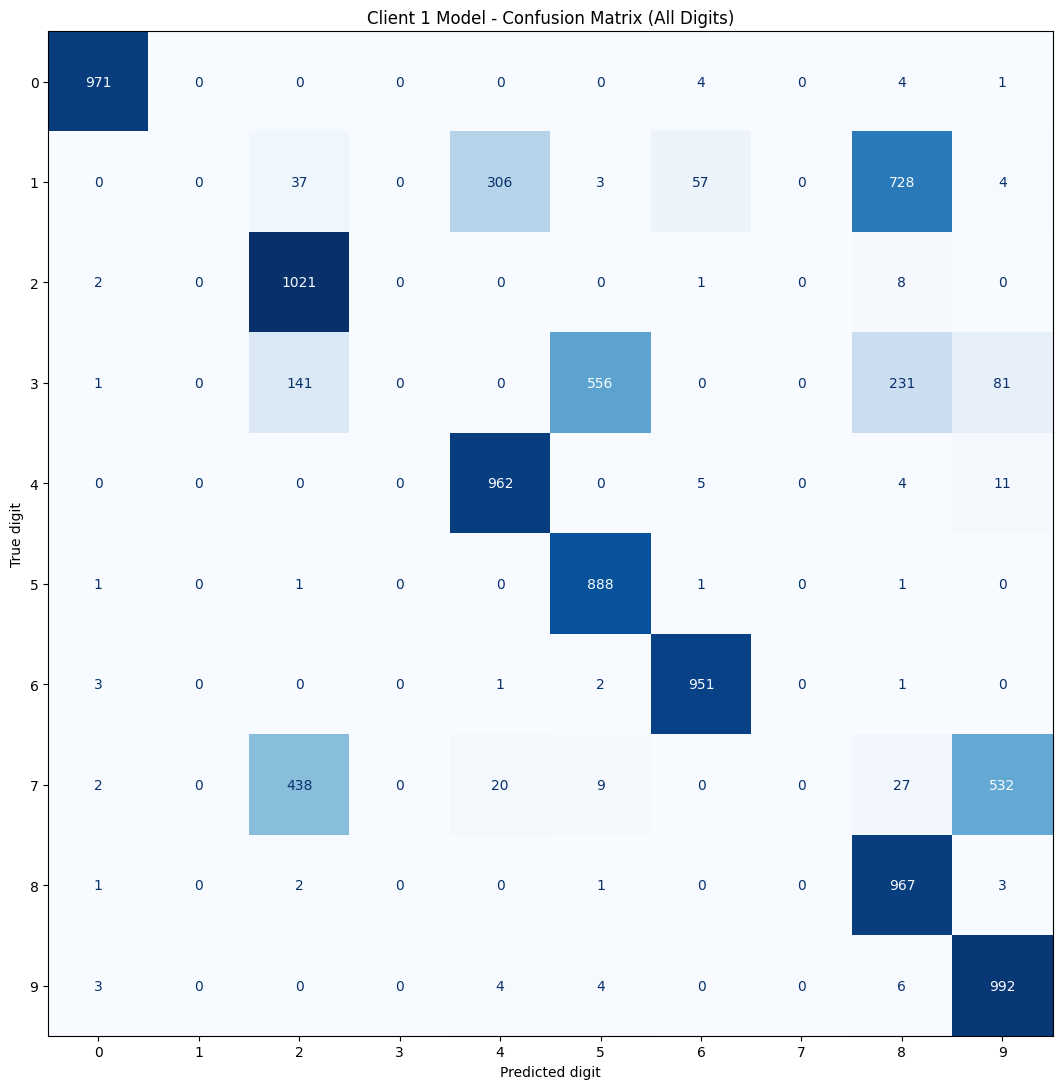

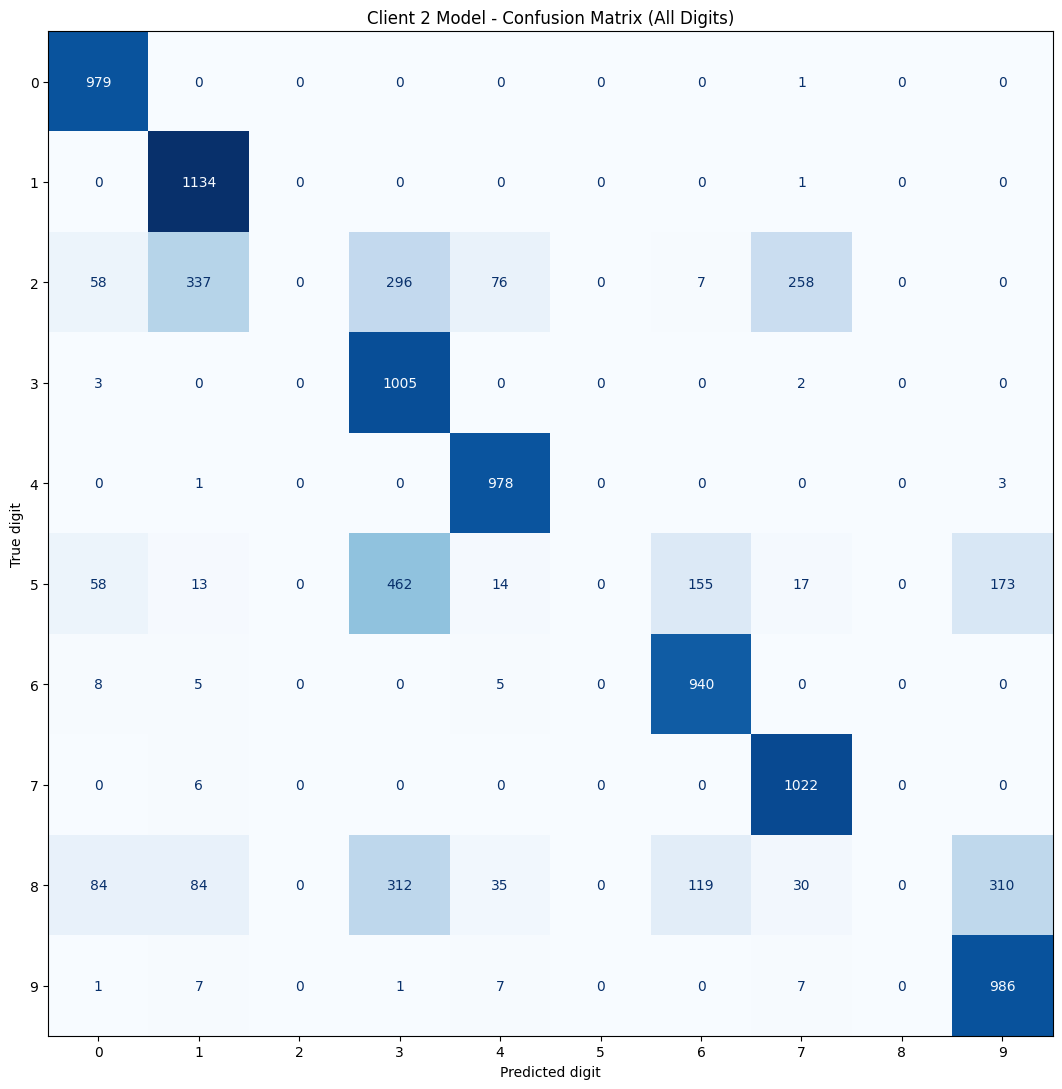

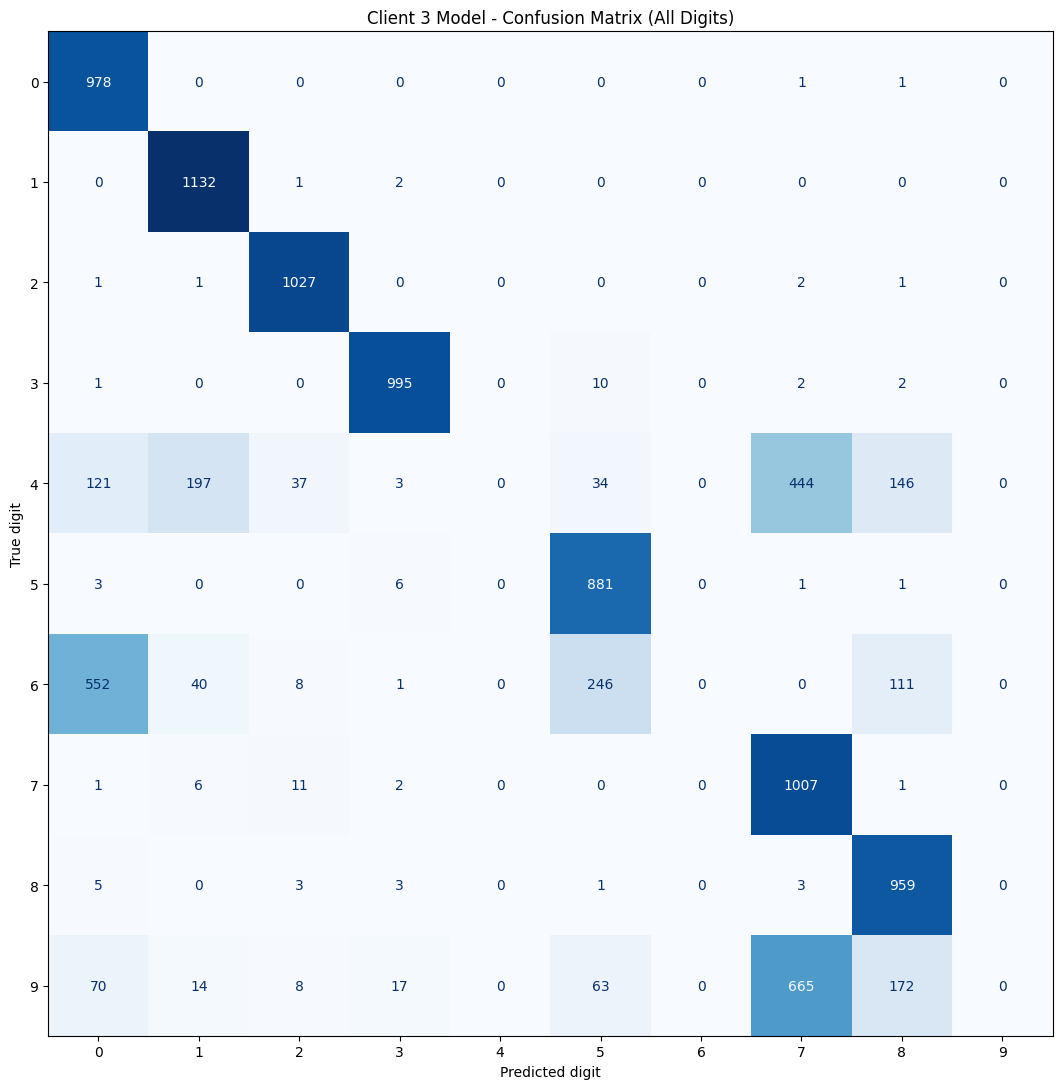

In [39]:
# Plot each local model on the complete global test set
plot_confusion_matrix_custom(
    client_1_model,
    testset,
    "Client 1 Model - Confusion Matrix (All Digits)",
)
plot_confusion_matrix_custom(
    client_2_model,
    testset,
    "Client 2 Model - Confusion Matrix (All Digits)",
)
plot_confusion_matrix_custom(
    client_3_model,
    testset,
    "Client 3 Model - Confusion Matrix (All Digits)",
)


### Key Takeaways

In this experiment, three independent CNN models were trained on different class-missing, non-IID MNIST partitions.

- Each model reached approximately **99% test accuracy on the digit classes it observed**.
- Each model reached **0% accuracy on its missing digit classes**.
- Overall accuracy fell to approximately **67% to 71%** because the global test set also contains those unseen classes.

The experiment demonstrates the limitation of **isolated local training on incomplete, heterogeneous data**. It is neither centralized learning, because the data are never pooled, nor federated learning, because model parameters are never exchanged or aggregated.

---

### Next Step: Federated Learning

The next notebook trains the clients collaboratively by sharing model updates rather than raw images. We will test whether aggregation allows one global model to learn all digit classes represented across the three clients.